In [1]:
import pandas as pd

In [3]:
def rename_columns(df, old_cols, new_cols):
    """
    Rename a series of columns using two aligned lists.
    """
    if len(old_cols) != len(new_cols):
        raise ValueError("old_cols and new_cols must have the same length")

    return df.rename(columns=dict(zip(old_cols, new_cols)))

In [11]:
# if args.type == 'txfr':

        ### transmission asset

file_loc = r"TXFR-T_REPLACEMENT LIST_01_12_26.xlsm"
df = pd.read_excel(file_loc, sheet_name = "Mar 2026 Repl Ranking by Phase", index_col=None, na_values=['NA'], skiprows=0)

sel_cols = ['SAP Equipment ID', 'Sub Name', 'Highest Cumulative POF ',
            'Reliability Risk Matrix (PoF,CoF)']

df_t_txfr = df[sel_cols]

df_t_txfr=rename_columns(df_t_txfr, ['SAP Equipment ID', 'Sub Name', 'Highest Cumulative POF '], 
                                ['Equipment', 'Substation Name', 'POF'])

df_t_txfr['line'] = 'T'

    ### distribution asset

file_loc = r"D_Transf_Risk_Ranking_Under_Const 2026.xlsx"
df = pd.read_excel(file_loc, sheet_name = "Distribution Transformers", index_col=None, na_values=['NA'], skiprows=0, engine='openpyxl')

sel_cols = ['SAP Equipment I.D.', 'Substation Name', 'Highest POF ','Reliability Risk Matrix (PoF,CoF)']

df_d_txfr = df[sel_cols]

df_d_txfr=rename_columns(df_d_txfr, ['SAP Equipment I.D.', 'Highest POF '], 
                        ['Equipment', 'POF'])

df_d_txfr['line'] = 'D'
# if args.line ==1:
asset_files = pd.concat([df_d_txfr, df_t_txfr])
# elif args.line ==2:
#     asset_files = df_t_txfr
# elif args.line == 3:
#     asset_files = df_d_txfr
# else:
#     raise ValueError('The line of the asset is not correctly selected. Choose between 1,2,3 (T&D, T, D, respectively).')
# asset_files['type'] = 'TXFR'

In [ ]:
asset_files.groupby('Equipment').count()[asset_files.groupby('Equipment').count()['Substation Name']==2]

,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line
Equipment,,,,
40989524,1,1,1,1
40989612,1,1,1,1
40989631,1,1,1,1
40989656,1,1,1,1
40989681,1,1,1,1
...,...,...,...,...
45764348,1,1,1,1
45781882,1,1,1,1
45783178,1,1,1,1


In [18]:
len(asset_files)

2379

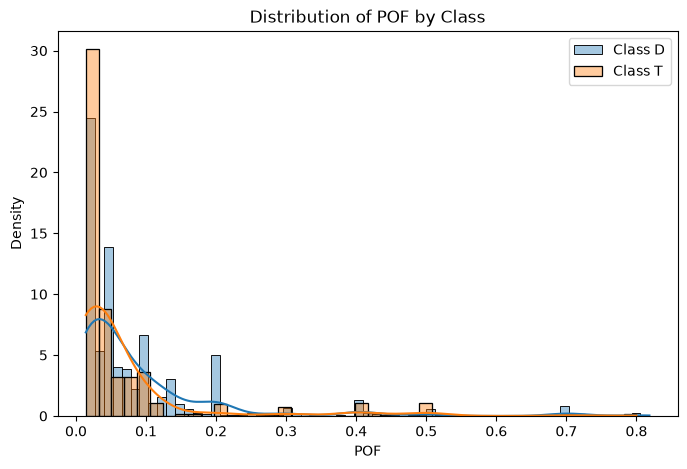

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_col = "line"      # column defining the classes
feature = "POF"      # feature to visualize

plt.figure(figsize=(8, 5))

for cls in asset_files[class_col].unique():
    sns.histplot(
        data=asset_files[asset_files[class_col] == cls],
        x=feature,
        kde=True,
        stat="density",
        label=f"Class {cls}",
        alpha=0.4
    )

plt.legend()
plt.title(f"Distribution of {feature} by Class")
plt.show()


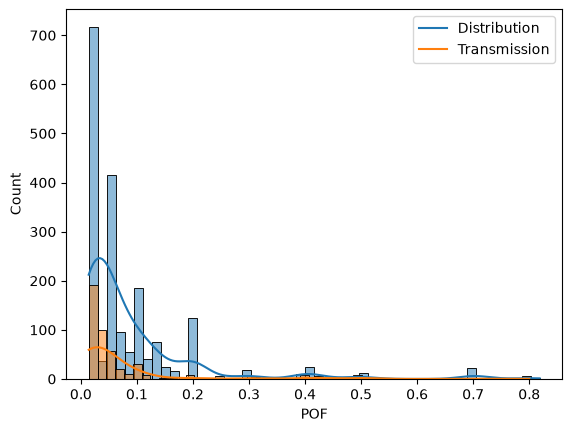

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=asset_files[asset_files['line']=='D'], x='POF', bins=50, kde=True)
sns.histplot(data=asset_files[asset_files['line']=='T'], x='POF', bins=50, kde=True)
plt.legend(['Distribution', 'Transmission'])
plt.show()

In [46]:
asset_files.POF.describe()

count    2379.000000
mean        0.085921
std         0.118741
min         0.014000
25%         0.020000
50%         0.050000
75%         0.100000
max         0.818520
Name: POF, dtype: float64

In [47]:
### transmission asset
file_loc = r"T_BRKR 1-N Under Const (1 15 2026).xlsx"
df = pd.read_excel(file_loc, sheet_name = "Transmission Breakers", index_col=None, na_values=['NA'], skiprows=0)

sel_cols = [' Equipment', 'Substation Name', 'Highest PoF',
            'Reliability Risk Matrix (PoF,CoF)']

df_t_brkr = df[sel_cols]


df_t_brkr=rename_columns(df_t_brkr, [' Equipment', 'Highest PoF'], 
                        ['Equipment', 'POF'])

df_t_brkr['line'] = 'T'
### distribution asset
file_loc = r"D BRKR 1-N Under Const 2026.xlsx"
df = pd.read_excel(file_loc, sheet_name = "Distribution Breakers", index_col=None, na_values=['NA'], skiprows=0, engine='openpyxl')

sel_cols = ['Equipment', 'Substation Name', 'Highest Cummulative PoF',
            'Reliability Risk Matrix (PoF,CoF)']

df_d_brkr = df[sel_cols]

df_d_brkr=rename_columns(df_d_brkr, ['Highest Cummulative PoF'], 
                        ['POF'])


df_d_brkr['line'] = 'D'


asset_files = pd.concat([df_d_brkr, df_t_brkr])

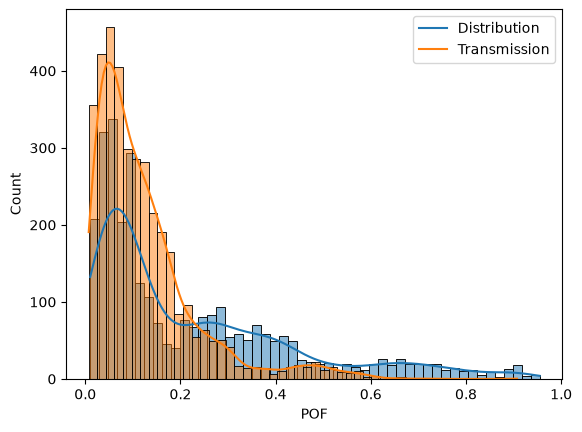

In [48]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=asset_files[asset_files['line']=='D'], x='POF', bins=50, kde=True)
sns.histplot(data=asset_files[asset_files['line']=='T'], x='POF', bins=50, kde=True)
plt.legend(['Distribution', 'Transmission'])
plt.show()

In [54]:
asset_files[asset_files['line']=='T'].POF.sum()

np.float64(459.08774347120044)